In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.coordinates import EarthLocation,SkyCoord
from astropy.time import Time, TimeDelta
from astropy import units as u
from astropy.coordinates import AltAz

In [2]:
def lst_to_local(sidereal_hours, location):
    """Convert local sidereal times to ref local time"""

    # Reference time to compute sidreal times
    ref_time = Time('2025-01-05 12:00:00', scale='utc')
    lst = ref_time.sidereal_time('apparent', longitude=location.lon)

    ret = []
    sidereal_hours = np.array(sidereal_hours, ndmin=1)
    for _lst_hour in sidereal_hours:
        dt_sec = (_lst_hour - lst.hour) * 3600
        ret.append(ref_time + TimeDelta(dt_sec, format='sec'))

    return ret

In [3]:
latitude_newhaven  = 41.31 # deg
longitude_newhaven = -72.923611 # deg
elevation_newhaven = 18 # m

lsts = np.linspace(0, 48, 200)
observing_location = EarthLocation(lat=latitude_newhaven, lon=longitude_newhaven, height=elevation_newhaven)
observing_time = lst_to_local(lsts, observing_location)
aa = AltAz(location=observing_location, obstime=observing_time)

coord = SkyCoord(20.62*360/24, 42.03, unit=(u.degree, u.degree), frame='icrs')
altaz = coord.transform_to(aa)


In [4]:
altaz.alt.value

array([53.28218564, 50.70543709, 48.14908672, 45.61496741, 43.10500002,
       40.62120168, 38.16569392, 35.74071079, 33.34860688, 30.99186516,
       28.67310457, 26.39508716, 24.16072465, 21.97308408, 19.83539233,
       17.75103911, 15.72357802, 13.75672521, 11.85435514, 10.0204929 ,
        8.25930239,  6.57506992,  4.97218259,  3.45510089,  2.02832531,
        0.69635661, -0.53635015, -1.66543743, -2.68670219, -3.59615696,
       -4.39009338, -5.06514635, -5.61835662, -6.04722912, -6.34978483,
       -6.52460349, -6.57085521, -6.48831929, -6.27738929, -5.93906399,
       -5.4749249 , -4.88710127, -4.1782246 , -3.35137469, -2.41001984,
       -1.35795359, -0.19923057,  1.06189664,  2.42103741,  3.87371882,
        5.41543582,  7.04169543,  8.74805475, 10.5301526 , 12.38373521,
       14.30467638, 16.28899251, 18.33285313, 20.43258765, 22.58468867,
       24.78581259, 27.03277798, 29.32256212, 31.65229611, 34.01925896,
       36.42087082, 38.85468572, 41.31838388, 43.80976379, 46.32

(-90.0, 90.0)

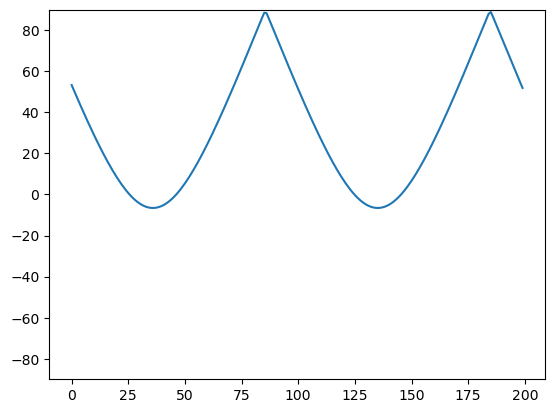

In [7]:
plt.plot(altaz.alt.value)
plt.ylim(-90, 90)

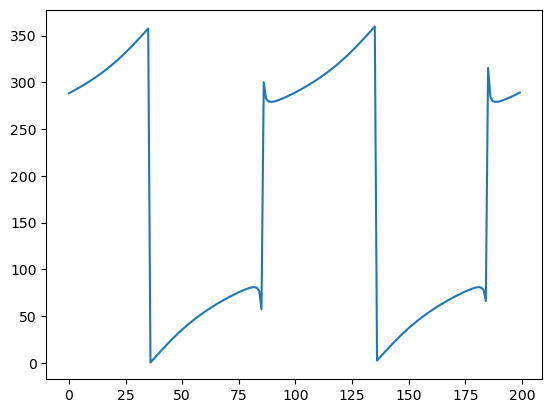

In [6]:
plt.plot(altaz.az.value)